In [1]:
!pip install langgraph

In [6]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [7]:
#defining the state
class BMIstate(TypedDict):
  weight_kg: float
  height_m: float
  bmi: float

In [14]:
# defining the bmi function
def cal_bmi(state: BMIstate) -> BMIstate:
  weight = state['weight_kg']
  height = state['height_m']

  #cal bmi
  bmi = weight/ (height**2)

  # updating the state
  state['bmi'] = round(bmi, 2)

  return state

In [15]:
# defining the graph
graph = StateGraph(BMIstate)
# defining the nodes
graph.add_node("calculating_bmi", cal_bmi)

# defining the edges
graph.add_edge(START, "calculating_bmi")
graph.add_edge("calculating_bmi", END)

In [16]:
#complining the graph
workflow = graph.compile()

# execute the graph
initial_state = {"weight_kg": 70, "height_m": 1.75}
output_state = workflow.invoke(initial_state)

print(output_state)

{'weight_kg': 70, 'height_m': 1.75, 'bmi': 22.86}


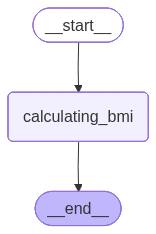

In [17]:
# visualize your workflow
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())